# Customer Service Workflow Agent

1. step 1: Classify user input into: Billing, Returns, Technical, Human Escalation
2. step 2: For Billing, Returns -> Add a process step/node which does the job

             For Technical: add node for answer generation, add node for answer validation and then response

            For Human Escalation: End

In [20]:
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-2.5-flash",configurable_fields={"temperature":1.8})

from pydantic import BaseModel, Field
from typing import TypedDict

# initialize the state data model
class Agentstate(TypedDict):
    user_query: str
    category:str
    response:str
    reasoning:str = ""
    technical_answer:str
    technical_validation:bool = False


# First node (classifier)

def classifier(state:Agentstate)->Agentstate:
    query = state['user_query']
    prompt = f""" You are expert query router, analyze the user query and identify the right intent of it, output one category from
    ['billing','technical','returns','human_escalation']
    Always follow below approach:
    1. billing: if the query is about payments, invoices, purchase orders, pricing, it is about billing
    2. returns: if the query is about returns, refunds, refund status, reorder, damaged products
    3. technical: if the query is about, product page crash, not able to login, account deactivated, payment failure, errors, 
    4. human_escalation: any other query
    Query: {query}
    """
    category = model.invoke(prompt).content
    return {"category":category}


In [21]:
classifier({"user_query":"payment page is crashing, how to resolve this"})

{'category': 'technical'}

In [ ]:
# Node 2: Billing
def billingnode(state:Agentstate)->Agentstate:
    query = state['user_query']
    prompt = f""" You are a BIlling query resolver, customer executive, be polite and professional. Understand the billing query and provide the answer to the question.
    Provide answer in 2 lines. 
    Query: {query}
    """
    response = model.invoke(prompt).content
    return {"response":response}

# Node 3: Returns
def returnsnode(state:Agentstate)->Agentstate:
    query = state['user_query']
    prompt = f""" You are a Returns order query resolver, customer executive, be polite and professional. 
    Understand the Return query and provide the appropriate answer to the question.
    Provide answer in 2 lines. 
    Query: {query}
    """
    response = model.invoke(prompt).content
    return {"response":response}

# Node 4: Technical Answer
def techansnode(state:Agentstate)->Agentstate:

    reasoning = state['reasoning']
    query = state['user_query']
    
    if len(reasoning)<5:
        prompt = f""" You are a Technical Expert for an E Commerce Platform, you are a customer executive, be polite and professional. 
        Understand the Return query and provide the appropriate answer to the question.
        Provide answer in 2 lines. 
        Query: {query}
        """
    else:
        technical_answer = state['technical_answer']
        prompt = f""" You are a Technical Expert for an E Commerce Platform, 
        you are a customer executive, be polite and professional. 
        Understand the Return query and provide the appropriate answer to the question.
        Following is a feedback for answer generated previously.
        Provide answer in 2 lines. 
        Query: {query}
        Previous incomplete/incorrect answer: {technical_answer}
        Reasoning: {reasoning}
        """


    technical_answer = model.invoke(prompt).content

    return {"technical_answer":technical_answer}

# Node 5: Technical Answer validation
def techvalidationnode(state:Agentstate)->Agentstate:
    query = state['user_query']
    technical_answer = state['technical_answer']

    class validaitonoutput(BaseModel):
        validation:bool = Field (description="Whether the answer provided is valid for the query or not: True for valid, False for invalid")
        reasoning:str = Field(description="Feedback for invalid answer to correct it, None for valid answer")

    prompt = f""" You are a senior technical customer service Manager,
     You need to validate an answer generated by another customer service executive.
    Make sure the answer is technically valid, if not generate a feedback for the technical expert to rework on the answer.
    Query: {query}
    Technical Answer: {technical_answer}
    """
    model2 = init_chat_model("google_genai:gemini-2.5-pro")
    validaiton_model = model2.with_structured_output(validaitonoutput)
    response = validaiton_model.invoke(prompt)
    if response.validation:
        return {"response":technical_answer, "technical_validation":response.validation,'reasoning':''}
    else:
        return {'reasoning':response.reasoning, "technical_validation":response.validation, 'response':technical_answer}
    





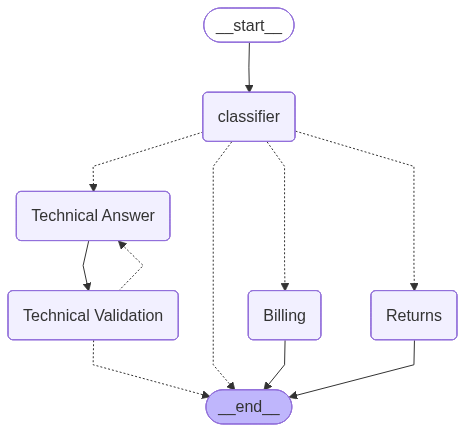

In [23]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(Agentstate)

builder.add_node("classifier",classifier)
builder.add_node("Technical Answer",techansnode)
builder.add_node("Technical Validation",techvalidationnode)
builder.add_node("Billing",billingnode)
builder.add_node("Returns",returnsnode)

def classification_route(state:Agentstate):
    if state['category']=='billing':
        return "Billing"
    elif state['category']=='returns':
        return "Returns"
    elif state['category']=='technical':
        return "Technical Answer"
    else:
        return END

builder.add_edge(START, "classifier")
builder.add_conditional_edges("classifier",classification_route,{"Billing":"Billing","Returns":"Returns",
                                                                 "Technical Answer":"Technical Answer",END:END})
builder.add_edge("Returns",END)
builder.add_edge("Billing",END)
builder.add_edge("Technical Answer","Technical Validation")

def technical_validation_routing(state:Agentstate):
    if state['technical_validation']:
        return END
    else: 
        return "Technical Answer"
builder.add_edge("Returns",END)
builder.add_conditional_edges("Technical Validation",technical_validation_routing,{"Technical Answer":"Technical Answer",END:END})

graph = builder.compile()
graph


In [24]:
graph.invoke({"user_query":"My payment failed and the page is crashing badly today, what to do now. ","reasoning":""})

{'user_query': 'My payment failed and the page is crashing badly today, what to do now. ',
 'category': 'technical',
 'response': "I apologize for the trouble you're experiencing with your payment and the crashing page.\nPlease try clearing your browser's cache and cookies, or use a different browser. If the issue persists, kindly contact our support team for further assistance.",
 'reasoning': '',
 'technical_answer': "I apologize for the trouble you're experiencing with your payment and the crashing page.\nPlease try clearing your browser's cache and cookies, or use a different browser. If the issue persists, kindly contact our support team for further assistance.",
 'technical_validation': True}